# Cyberattack Classification Using Machine Learning
### Machine Learning Project 

---

## Project Overview
Organizations experience diverse cyber threats, including Denial-of-Service (DoS), port scanning/probing, brute-force credential stuffing, and unauthorized privilege escalation. Rapid and automated threat identification at the network perimeter enables Security Operations Center (SOC) teams to mitigate malicious activity before critical infrastructure is compromised.

### Core Objectives:
1. **Ingest & Preprocess Network Traffic Data**: Load the benchmark **NSL-KDD** dataset, map granular attack vectors into 5 primary operational categories (`Normal`, `DoS`, `Probe`, `Brute Force`, `Other Attack`), and construct an end-to-end transformation pipeline.
2. **Conduct Exploratory Data Analysis (EDA)**: Identify traffic volume patterns, protocol preferences, connection flag anomalies, and class distribution imbalances.
3. **Train & Evaluate 6 Classical ML Algorithms**:
   * Logistic Regression
   * K-Nearest Neighbors (KNN)
   * Decision Tree
   * Random Forest
   * Naive Bayes (Gaussian NB)
   * Gradient Boosting
4. **Conduct a Rigorous Comparative Study**: Evaluate performance across Accuracy, Macro Precision, Macro Recall, Macro F1-Score, and Confusion Matrices.
5. **Analyze Class Balancing & Novel Attacks**: Test the impact of class balancing (SMOTE) and evaluate zero-day attack generalization on 17 novel attack types in the test set.
6. **Prepare for Deployment**: Export the top-performing pipeline for real-time inference in an interactive application.


### 0. Environment Setup & Dependencies
Below we install and import all necessary libraries for data manipulation, visualization, machine learning, and model persistence. If running in a new environment, uncomment the pip install command below.

In [1]:
import os
os.environ['MPLCONFIGDIR'] = os.path.join(os.getcwd(), '.matplotlib_cache')
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)
# Uncomment and run if packages are not already installed:
# %pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Metrics
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# The 6 Required Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Class Balancing
from imblearn.over_sampling import SMOTE

# Persistence
import joblib

# Formatting and warnings configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Libraries imported successfully!")


Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


---
## 1. Data Ingestion & Understanding

**Process Explanation:**
Data Ingestion loads the raw network connection records and establishes standard column headers since raw NSL-KDD files lack header rows. Inspecting data types, record counts, and missing values ensures structural integrity before any transformations occur.


In [5]:
# Define standard NSL-KDD feature names (41 network features + label + difficulty_level)
FEATURE_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# Set data paths
DATA_DIR = 'NSL-KDD'
TRAIN_PATH = os.path.join(DATA_DIR, 'KDDTrain+.txt')
TEST_PATH = os.path.join(DATA_DIR, 'KDDTest+.txt')
TRAIN_20P_PATH = os.path.join(DATA_DIR, 'KDDTrain+_20Percent.txt')

# Choose dataset for training:
# Set USE_20_PERCENT_TRAIN = True for faster training (ideal for KNN / hyperparameter tuning)
# Set USE_20_PERCENT_TRAIN = False for the full 125,973 training instances
USE_20_PERCENT_TRAIN = True
active_train_path = TRAIN_20P_PATH if USE_20_PERCENT_TRAIN else TRAIN_PATH

print(f"Loading training data from: {active_train_path}")
df_train = pd.read_csv(active_train_path, names=FEATURE_NAMES)
df_test = pd.read_csv(TEST_PATH, names=FEATURE_NAMES)

print(f"Training dataset shape: {df_train.shape} (rows, columns)")
print(f"Testing dataset shape:  {df_test.shape} (rows, columns)")


Loading training data from: NSL-KDD/KDDTrain+_20Percent.txt
Training dataset shape: (25192, 43) (rows, columns)
Testing dataset shape:  (22544, 43) (rows, columns)


In [6]:
# Display sample records from the training set
print("First 5 records of raw data:")
display(df_train.head(5))

print("\nMissing values check:")
print(f"Train nulls: {df_train.isnull().sum().sum()}")
print(f"Test nulls:  {df_test.isnull().sum().sum()}")


First 5 records of raw data:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  num_failed_logins  logged_in  num_compromised  root_shell  su_attempted  num_root  num_file_creations  num_shells  num_access_files  num_outbound_cmds  is_host_login  is_guest_login  count  srv_count  serror_rate  srv_serror_rate  rerror_rate  srv_rerror_rate  same_srv_rate  diff_srv_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  dst_host_srv_rerror_rate    label  difficulty_level
0         0           tcp  ftp_data   SF        491          0     0               0       0    0                  0          0                0           0             0         0                   0           0                 0                  0              0               0      2          

---
## 2. Data Preprocessing & Target Mapping

**Process Explanation:**
Raw NSL-KDD labels contain over 38 individual attack variants, which are mapped into 5 operational categories (`Normal`, `DoS`, `Probe`, `Brute Force`, `Other Attack`) to align with project requirements. We also drop the auxiliary `difficulty_level` column which is not a network traffic feature.


In [8]:
# 5-Class Target Mapping Dictionary
# Maps granular attack vectors into 5 operational threat categories
ATTACK_MAPPING = {
    'normal': 'Normal',
    
    # Denial of Service (DoS): Flooding network resources to deny legitimate access
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS', 'smurf': 'DoS',
    'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS', 'processtable': 'DoS',
    'udpstorm': 'DoS',
    
    # Probe: Scanning and reconnaissance to map network topology and vulnerabilities
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',
    
    # Brute Force / Remote to Local (R2L): Password cracking, unauthorized credential access
    'guess_passwd': 'Brute Force', 'ftp_write': 'Brute Force', 'imap': 'Brute Force',
    'phf': 'Brute Force', 'multihop': 'Brute Force', 'warezmaster': 'Brute Force',
    'warezclient': 'Brute Force', 'spy': 'Brute Force', 'snmpgetattack': 'Brute Force',
    'snmpguess': 'Brute Force', 'named': 'Brute Force', 'sendmail': 'Brute Force',
    'xlock': 'Brute Force', 'xsnoop': 'Brute Force', 'httptunnel': 'Brute Force',
    
    # Other Attack / User to Root (U2R): Privilege escalation and malicious code execution
    'buffer_overflow': 'Other Attack', 'loadmodule': 'Other Attack', 'rootkit': 'Other Attack',
    'perl': 'Other Attack', 'sqlattack': 'Other Attack', 'xterm': 'Other Attack',
    'ps': 'Other Attack', 'worm': 'Other Attack'
}

# Apply mapping
df_train['attack_category'] = df_train['label'].map(ATTACK_MAPPING)
df_test['attack_category'] = df_test['label'].map(ATTACK_MAPPING)

# Drop difficulty level (not a traffic feature)
df_train.drop(columns=['difficulty_level'], inplace=True)
df_test.drop(columns=['difficulty_level'], inplace=True)

# Identify novel zero-day attack variants present ONLY in the test set
train_attacks = set(df_train['label'].unique())
test_attacks = set(df_test['label'].unique())
novel_attacks = test_attacks - train_attacks

print(f"Total granular attack types in Train: {len(train_attacks)}")
print(f"Total granular attack types in Test:  {len(test_attacks)}")
print(f"Novel (zero-day) attack types in Test only: {len(novel_attacks)}")
print(f"Novel attacks list: {sorted(list(novel_attacks))}")


Total granular attack types in Train: 22
Total granular attack types in Test:  38
Novel (zero-day) attack types in Test only: 18
Novel attacks list: ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'perl', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


In [9]:
# Display mapped 5-class distributions
train_dist = df_train['attack_category'].value_counts()
train_pct = df_train['attack_category'].value_counts(normalize=True) * 100
test_dist = df_test['attack_category'].value_counts()
test_pct = df_test['attack_category'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Train Count': train_dist,
    'Train %': train_pct.round(2),
    'Test Count': test_dist,
    'Test %': test_pct.round(2)
})
print("5-Class Threat Distribution Summary:")
display(summary_df)


5-Class Threat Distribution Summary:
                 Train Count  Train %  Test Count  Test %
attack_category                                          
Brute Force              209     0.83        2885   12.80
DoS                     9234    36.65        7458   33.08
Normal                 13449    53.39        9711   43.08
Other Attack              11     0.04          69    0.31
Probe                   2289     9.09        2421   10.74


---
## 3. Exploratory Data Analysis (EDA)

**Process Explanation:**
Exploratory Data Analysis visualizes underlying statistical distributions, network protocol signatures, and class imbalances across benign and malicious traffic. These insights guide feature engineering and reveal which network features effectively separate threat classes.


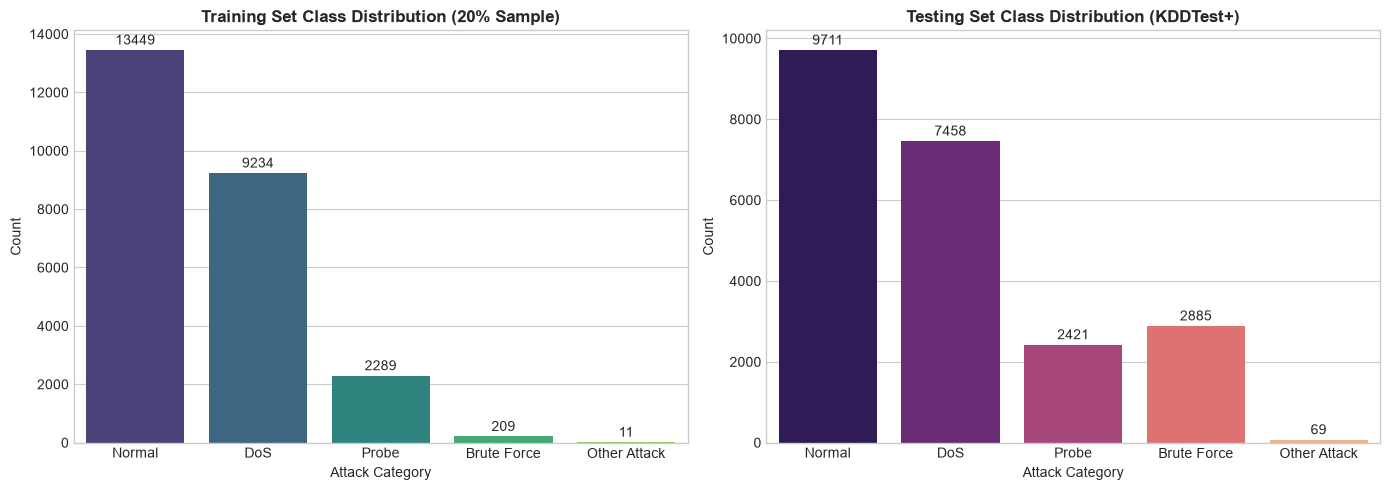

In [11]:
# 3.1 Class Distribution Comparison (Train vs. Test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df_train, x='attack_category', ax=axes[0], 
    order=['Normal', 'DoS', 'Probe', 'Brute Force', 'Other Attack'],
    palette='viridis'
)
axes[0].set_title(f"Training Set Class Distribution ({'20% Sample' if USE_20_PERCENT_TRAIN else 'Full'})", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Attack Category")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, xytext=(0, 4), textcoords='offset points')

sns.countplot(
    data=df_test, x='attack_category', ax=axes[1],
    order=['Normal', 'DoS', 'Probe', 'Brute Force', 'Other Attack'],
    palette='magma'
)
axes[1].set_title("Testing Set Class Distribution (KDDTest+)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Attack Category")
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.show()


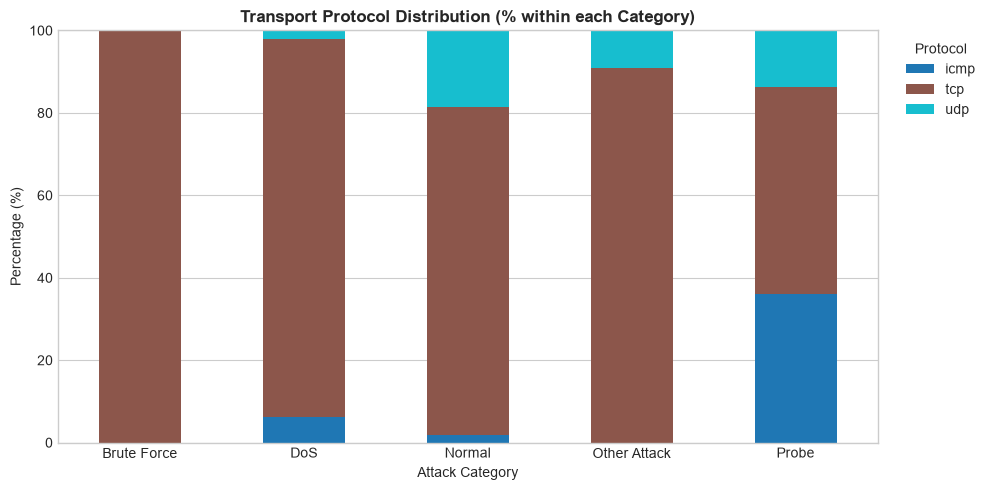

In [12]:
# 3.2 Protocol Distribution Across Attack Categories
fig, ax = plt.subplots(figsize=(10, 5))
proto_ct = pd.crosstab(df_train['attack_category'], df_train['protocol_type'], normalize='index') * 100
proto_ct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title("Transport Protocol Distribution (% within each Category)", fontsize=12, fontweight='bold')
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Attack Category")
ax.legend(title="Protocol", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


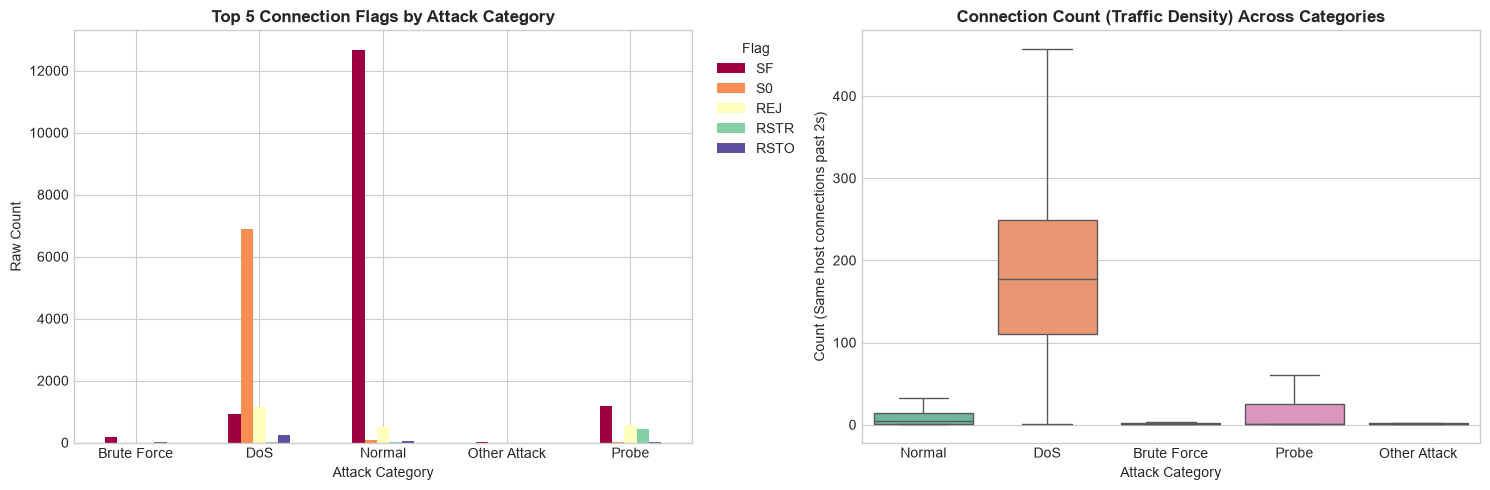

In [13]:
# 3.3 Connection Flag Analysis (Network Security Context)
# In TCP/IP, flag S0 indicates a SYN flood attempt (SYN received without complete handshake)
# Flag SF indicates normal SYN/FIN established and closed connections
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_flags = df_train['flag'].value_counts().head(5).index
flag_ct = pd.crosstab(df_train['attack_category'], df_train['flag'])[top_flags]

flag_ct.plot(kind='bar', ax=axes[0], colormap='Spectral')
axes[0].set_title("Top 5 Connection Flags by Attack Category", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Raw Count")
axes[0].set_xlabel("Attack Category")
axes[0].legend(title="Flag", bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

# 3.4 Key Numerical Features: Comparison of Traffic Rates
# Analyzing 'count' (connections to same host in past 2 seconds) and 'serror_rate' (SYN error rate)
sns.boxplot(data=df_train, x='attack_category', y='count', ax=axes[1], palette='Set2', showfliers=False)
axes[1].set_title("Connection Count (Traffic Density) Across Categories", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Count (Same host connections past 2s)")
axes[1].set_xlabel("Attack Category")

plt.tight_layout()
plt.show()


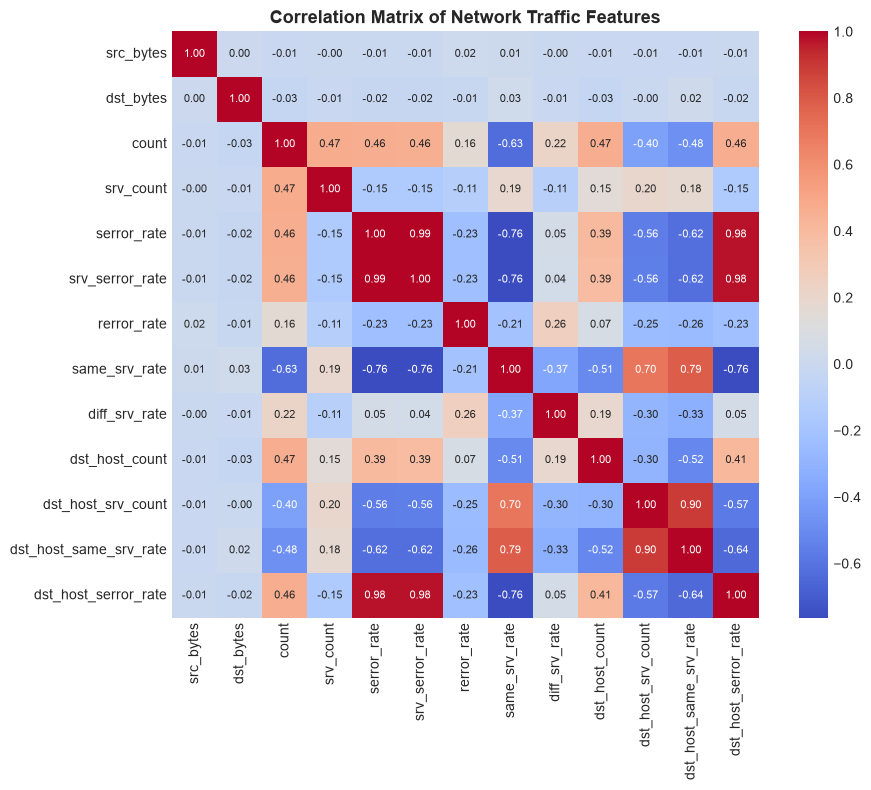

In [14]:
# 3.5 Correlation Heatmap of Key Numerical Traffic Features
key_numeric_features = [
    'src_bytes', 'dst_bytes', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_serror_rate'
]

plt.figure(figsize=(10, 8))
corr_matrix = df_train[key_numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True, annot_kws={'size': 8})
plt.title("Correlation Matrix of Network Traffic Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Feature Engineering & Preprocessing Pipeline

**Process Explanation:**
Network data contains categorical attributes (`protocol_type`, `service`, `flag`) requiring One-Hot Encoding, while continuous numerical attributes span vastly different orders of magnitude and require standard scaling. Transformers are fit strictly on the training set to prevent data leakage into testing evaluation.


In [16]:
# Separate Features and Targets
X_train_raw = df_train.drop(columns=['label', 'attack_category'])
y_train_raw = df_train['attack_category']

X_test_raw = df_test.drop(columns=['label', 'attack_category'])
y_test_raw = df_test['attack_category']

# Identify categorical and numerical column subsets
cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features ({len(num_cols)}): {len(num_cols)} features")


Categorical features (3): ['protocol_type', 'service', 'flag']
Numerical features (38): 38 features


In [17]:
# Build Scikit-Learn Preprocessing ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Fit on training data and transform both train and test
print("Fitting preprocessor on training data...")
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Encode categorical target labels into numerical integers
label_encoder = LabelEncoder()
target_classes = ['Normal', 'DoS', 'Probe', 'Brute Force', 'Other Attack']
label_encoder.fit(target_classes)

y_train = label_encoder.transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

encoded_feature_names = num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))

print(f"Transformed X_train shape: {X_train.shape}")
print(f"Transformed X_test shape:  {X_test.shape}")
print(f"Total encoded features:    {len(encoded_feature_names)}")
print(f"Target classes mapping:    {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


Fitting preprocessor on training data...
Transformed X_train shape: (25192, 118)
Transformed X_test shape:  (22544, 118)
Total encoded features:    118
Target classes mapping:    {np.str_('Brute Force'): np.int64(0), np.str_('DoS'): np.int64(1), np.str_('Normal'): np.int64(2), np.str_('Other Attack'): np.int64(3), np.str_('Probe'): np.int64(4)}


---
## 5. Class Balancing Analysis (Research Question 5)

**Process Explanation:**
Network intrusion datasets suffer from extreme class disparity where benign and DoS events outnumber rare attacks like Brute Force and Other Attack (privilege escalation) by orders of magnitude. We apply SMOTE (Synthetic Minority Over-sampling Technique) to generate balanced training representations and address Question 5.


In [19]:
# Check initial class balance
unique, counts = np.unique(y_train, return_counts=True)
initial_class_counts = dict(zip(label_encoder.inverse_transform(unique), counts))
print("Initial Training Class Distribution:")
for cls, cnt in initial_class_counts.items():
    print(f"  {cls:<15}: {cnt:>6} samples ({cnt / len(y_train) * 100:.2f}%)")

# Apply SMOTE to balance the minority classes in training set
# (Note: k_neighbors=3 ensures classes with small sample counts can be oversampled cleanly)
print("\nApplying SMOTE (Synthetic Minority Over-sampling)...")
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

unique_b, counts_b = np.unique(y_train_balanced, return_counts=True)
balanced_class_counts = dict(zip(label_encoder.inverse_transform(unique_b), counts_b))
print("Balanced Training Class Distribution:")
for cls, cnt in balanced_class_counts.items():
    print(f"  {cls:<15}: {cnt:>6} samples")
print(f"Total samples before SMOTE: {len(y_train)} -> after SMOTE: {len(y_train_balanced)}")


Initial Training Class Distribution:
  Brute Force    :    209 samples (0.83%)
  DoS            :   9234 samples (36.65%)
  Normal         :  13449 samples (53.39%)
  Other Attack   :     11 samples (0.04%)
  Probe          :   2289 samples (9.09%)

Applying SMOTE (Synthetic Minority Over-sampling)...
Balanced Training Class Distribution:
  Brute Force    :  13449 samples
  DoS            :  13449 samples
  Normal         :  13449 samples
  Other Attack   :  13449 samples
  Probe          :  13449 samples
Total samples before SMOTE: 25192 -> after SMOTE: 67245


---
## 6. Model Training & Evaluation (The 6 Required Algorithms)

**Process Explanation:**
We systematically train the six machine learning algorithms specified in the project requirements:
1. **Logistic Regression**: Linear multi-class baseline using cross-entropy loss.
2. **K-Nearest Neighbors (KNN)**: Non-parametric instance-based classifier evaluating distance metrics.
3. **Decision Tree**: Non-linear, interpretable axis-aligned partitioning model.
4. **Random Forest**: Ensemble bagging method combining randomized decorrelated decision trees.
5. **Naive Bayes**: Probabilistic classifier applying Bayes' theorem with feature independence assumptions.
6. **Gradient Boosting**: Sequential boosting model that builds trees to correct pseudo-residuals.

Each model is evaluated on the independent official test set (`KDDTest+`) using Accuracy, Macro Precision, Macro Recall, Macro F1-score, and training runtimes.


In [21]:
# Instantiate the 6 algorithms with reproducible configurations
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=15),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=RANDOM_SEED)
}

# Storage for comparative metrics and predictions
results_list = []
trained_models = {}
test_predictions = {}

print("Beginning model training and evaluation pipeline...")
print("=" * 70)

for name, model in models.items():
    print(f"--> Training {name}...")
    start_time = time.time()
    
    # Train the model (using balanced training set for robust multi-class generalization)
    model.fit(X_train_balanced, y_train_balanced)
    train_time = time.time() - start_time
    
    # Evaluate on the unseen official test set (KDDTest+)
    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred
    
    # Calculate required multi-class metrics
    acc = accuracy_score(y_test, y_pred)
    macro_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    macro_rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Save artifacts
    trained_models[name] = model
    test_predictions[name] = y_pred
    
    results_list.append({
        "Algorithm": name,
        "Accuracy": acc,
        "Macro Precision": macro_prec,
        "Macro Recall": macro_rec,
        "Macro F1-score": macro_f1,
        "Train Time (s)": round(train_time, 2),
        "Inference Time (s)": round(pred_time, 2)
    })
    
    print(f"    Completed in {train_time:.2f}s | Acc: {acc:.4f} | Macro F1: {macro_f1:.4f}")

print("=" * 70)
print("All 6 models successfully trained and evaluated!")


Beginning model training and evaluation pipeline...
--> Training Logistic Regression...
    Completed in 4.50s | Acc: 0.7970 | Macro F1: 0.6802
--> Training K-Nearest Neighbors...
    Completed in 0.00s | Acc: 0.7552 | Macro F1: 0.5885
--> Training Decision Tree...
    Completed in 0.44s | Acc: 0.7416 | Macro F1: 0.4720
--> Training Random Forest...
    Completed in 0.92s | Acc: 0.7437 | Macro F1: 0.4955
--> Training Naive Bayes...
    Completed in 0.04s | Acc: 0.5467 | Macro F1: 0.4292
--> Training Gradient Boosting...
    Completed in 131.07s | Acc: 0.7615 | Macro F1: 0.5360
All 6 models successfully trained and evaluated!


---
## 7. Comparative Study & Visual Evaluation

**Process Explanation:**
The comparative study synthesizes performance across all models into standardized comparison tables and visual metric benchmarks. We specifically focus on **Macro F1-score** rather than raw accuracy, because macro metrics treat rare attack classes with equal importance to majority benign traffic.


In [23]:
# 7.1 Performance Comparison Table
df_results = pd.DataFrame(results_list).sort_values(by='Macro F1-score', ascending=False).reset_index(drop=True)

print("SUMMARY COMPARATIVE STUDY TABLE:")
try:
    display(df_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1-score": "{:.4f}",
        "Train Time (s)": "{:.2f}",
        "Inference Time (s)": "{:.2f}"
    }).highlight_max(subset=['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-score'], color='lightgreen'))
except Exception:
    display(df_results)


SUMMARY COMPARATIVE STUDY TABLE:
 Algorithm Accuracy Macro Precision Macro Recall Macro F1-score Train Time (s) Inference Time (s)
0 Logistic Regression 0.7970 0.7564 0.6591 0.6802 4.50 0.00
1 K-Nearest Neighbors 0.7552 0.7864 0.5749 0.5885 0.00 1.47
2 Gradient Boosting 0.7615 0.7049 0.5297 0.5360 131.07 0.11
3 Random Forest 0.7437 0.8123 0.4839 0.4955 0.92 0.03
4 Decision Tree 0.7416 0.4911 0.5083 0.4720 0.44 0.00
5 Naive Bayes 0.5467 0.4484 0.4953 0.4292 0.04 0.02



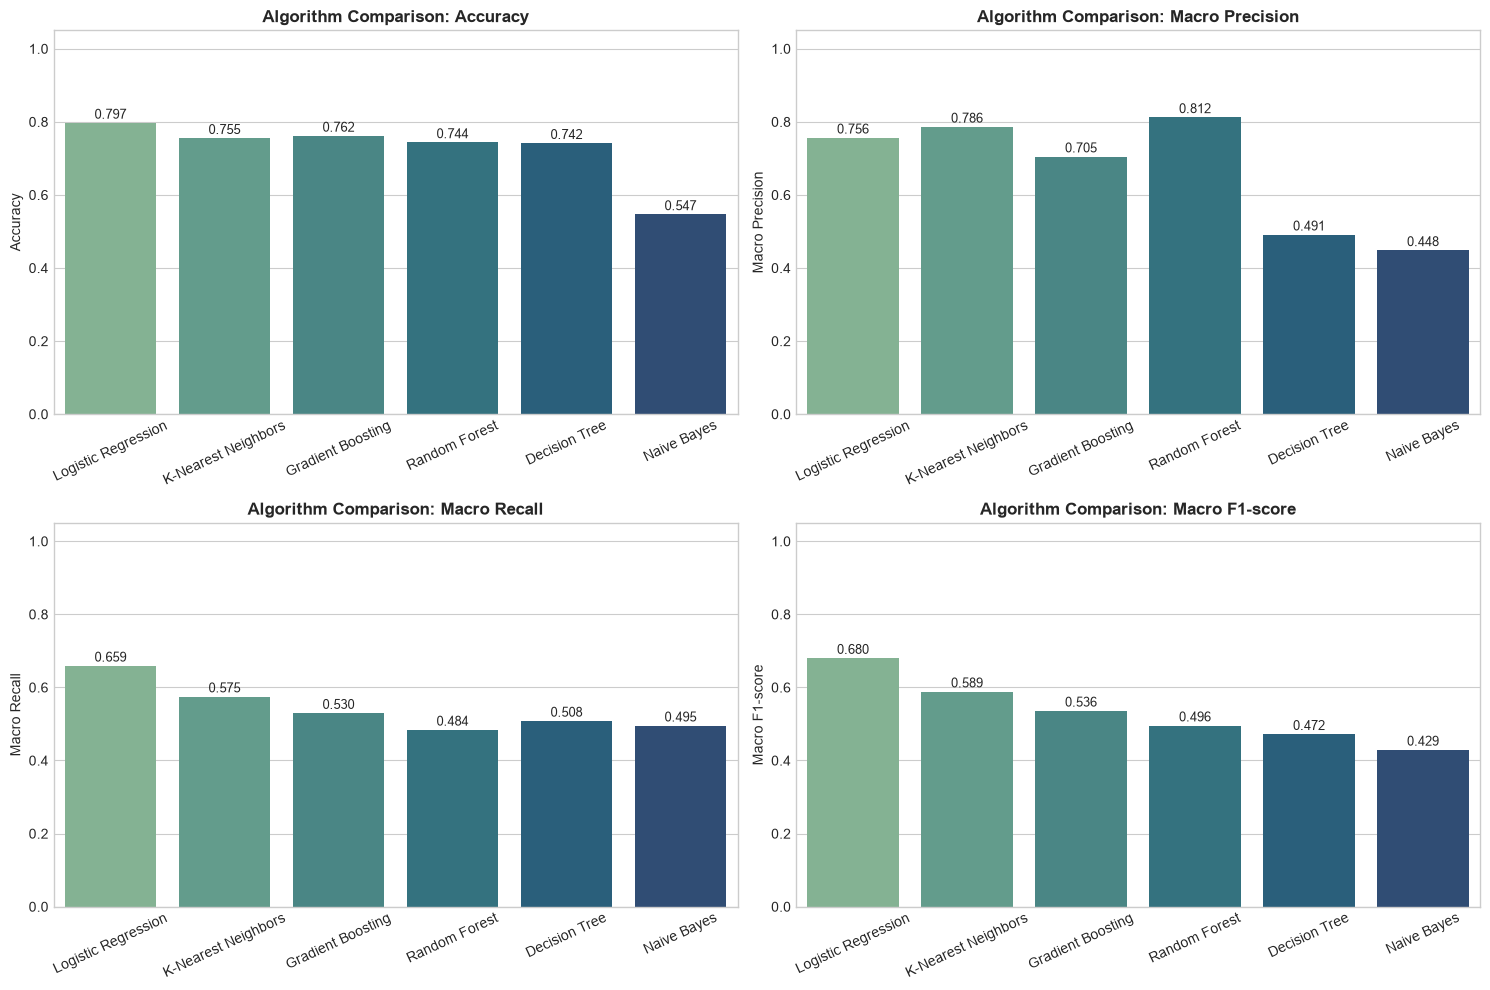

In [24]:
# 7.2 Graphical Comparison of Evaluation Metrics
metrics_to_plot = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-score']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    sns.barplot(
        data=df_results, x='Algorithm', y=metric, ax=axes[idx],
        palette='crest'
    )
    axes[idx].set_title(f"Algorithm Comparison: {metric}", fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 1.05)
    axes[idx].set_ylabel(metric)
    axes[idx].set_xlabel("")
    axes[idx].tick_params(axis='x', rotation=25)
    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='baseline', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


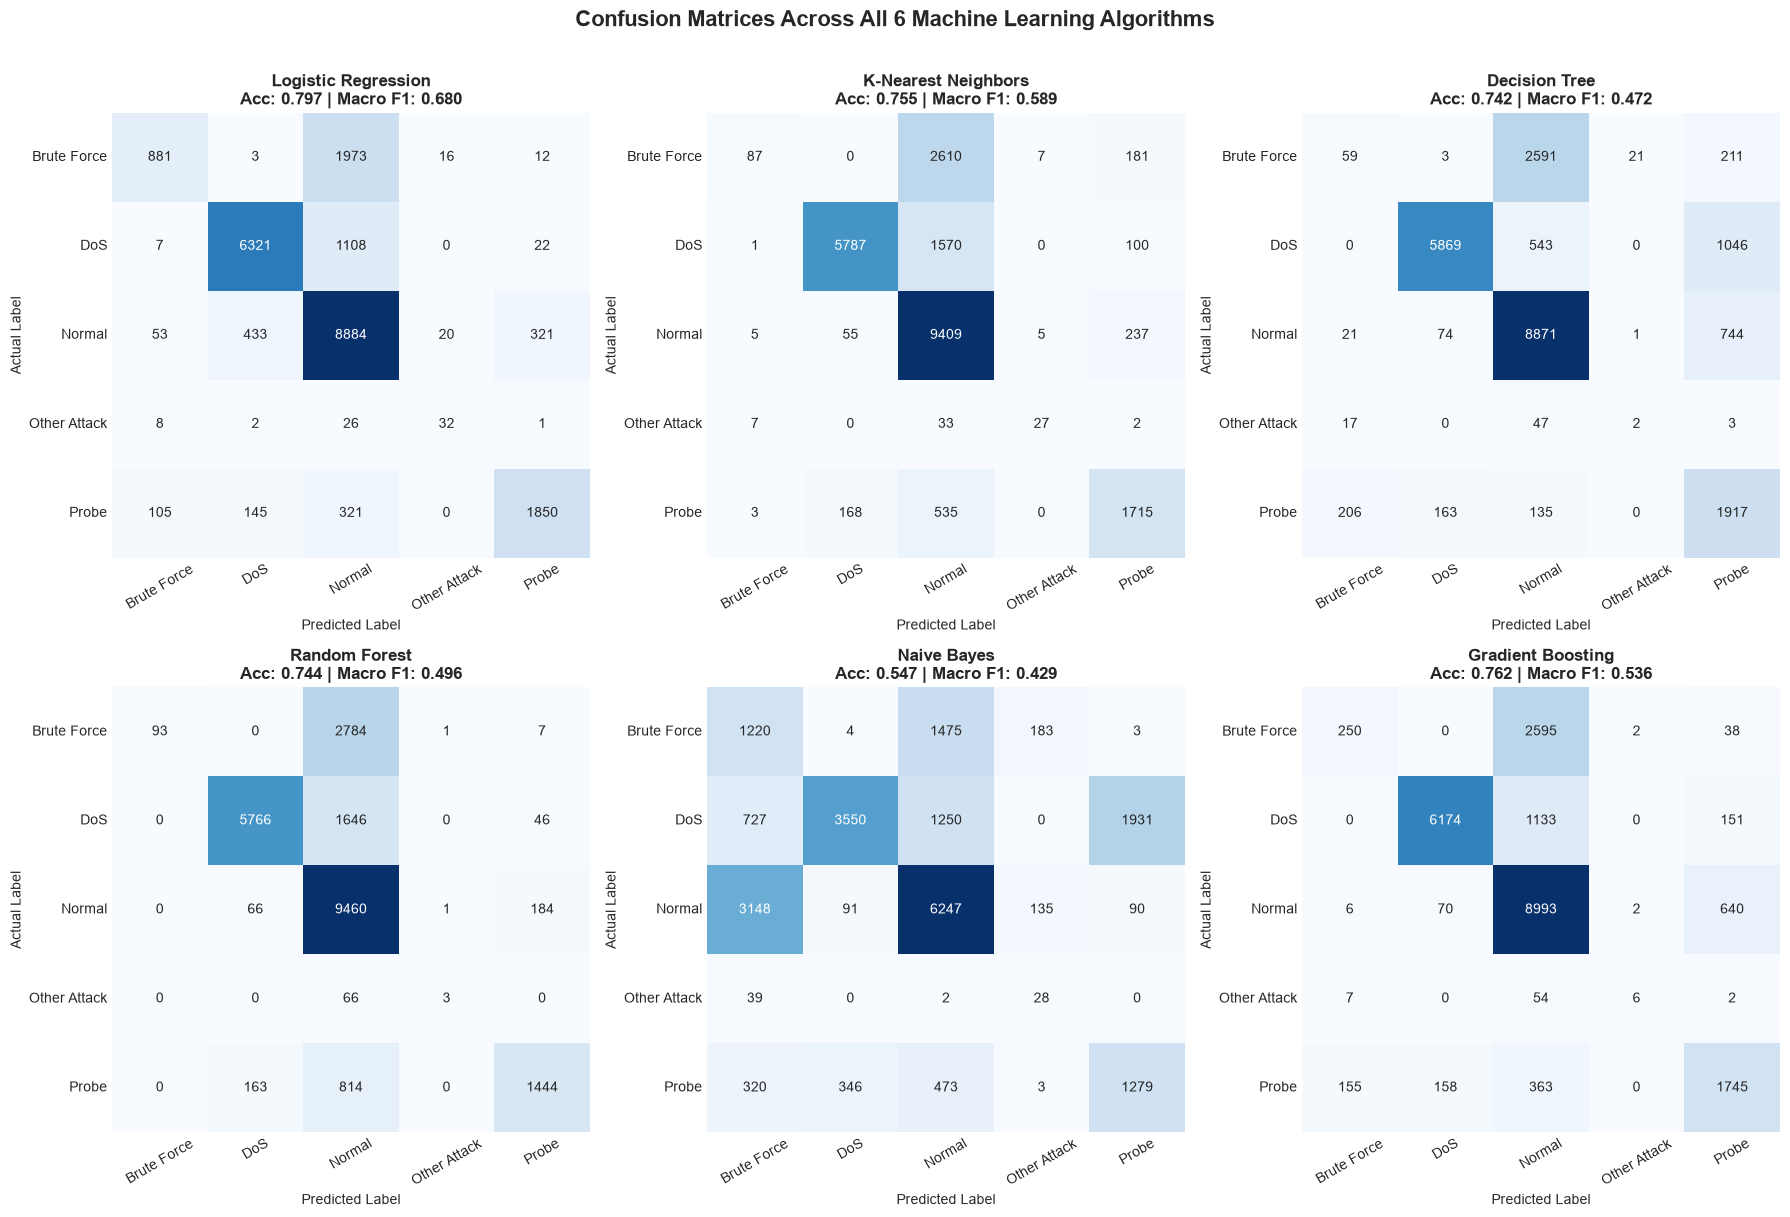

In [25]:
# 7.3 Confusion Matrix Analysis for All 6 Models
target_names = label_encoder.classes_
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(test_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=target_names, yticklabels=target_names, cbar=False
    )
    axes[idx].set_title(f"{name}\nAcc: {accuracy_score(y_test, y_pred):.3f} | Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}", fontweight='bold')
    axes[idx].set_ylabel("Actual Label")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].tick_params(axis='y', rotation=0)

plt.suptitle("Confusion Matrices Across All 6 Machine Learning Algorithms", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [26]:
# 7.4 Detailed Per-Class Classification Report for the Best Model
best_model_name = df_results.iloc[0]['Algorithm']
best_pred = test_predictions[best_model_name]

print(f"=== Detailed Classification Report for Best Model: {best_model_name} ===")
print(classification_report(y_test, best_pred, target_names=target_names, digits=4))


=== Detailed Classification Report for Best Model: Logistic Regression ===
              precision    recall  f1-score   support

 Brute Force     0.8359    0.3054    0.4473      2885
         DoS     0.9156    0.8475    0.8802      7458
      Normal     0.7216    0.9148    0.8068      9711
Other Attack     0.4706    0.4638    0.4672        69
       Probe     0.8386    0.7641    0.7997      2421

    accuracy                         0.7970     22544
   macro avg     0.7564    0.6591    0.6802     22544
weighted avg     0.8122    0.7970    0.7833     22544



---
## 8. Feature Importance Analysis (Research Question 2)

**Process Explanation:**
Feature importance reveals the decision logic of tree-based ensembles by computing mean decrease in impurity (Gini importance). Ranking the top features identifies which network telemetry signals are most critical for isolating cyber threats.


Top 5 Network Threat Differentiators:
  1. src_bytes                      (Importance: 0.0710)
  2. dst_bytes                      (Importance: 0.0650)
  3. dst_host_srv_count             (Importance: 0.0632)
  4. logged_in                      (Importance: 0.0519)
  5. dst_host_same_src_port_rate    (Importance: 0.0418)


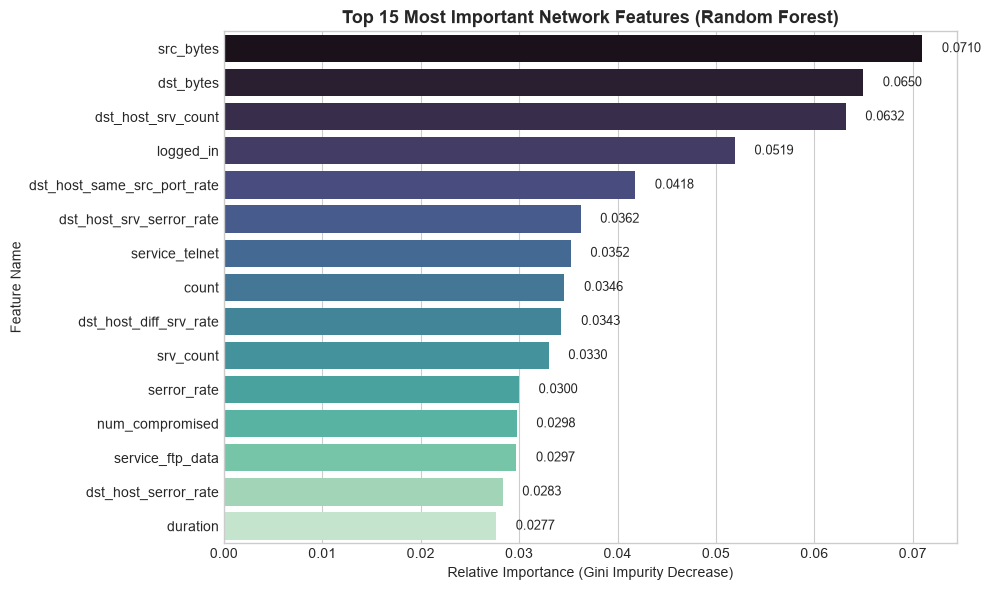

In [28]:
# Extract feature importances from Random Forest
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_
top_n = 15

# Sort indices by importance
indices = np.argsort(importances)[::-1][:top_n]
top_features = [encoded_feature_names[i] for i in indices]
top_values = importances[indices]

# Plot Top 15 Important Features
plt.figure(figsize=(10, 6))
sns.barplot(x=top_values, y=top_features, palette='mako')
plt.title(f"Top {top_n} Most Important Network Features (Random Forest)", fontsize=13, fontweight='bold')
plt.xlabel("Relative Importance (Gini Impurity Decrease)")
plt.ylabel("Feature Name")

for idx, val in enumerate(top_values):
    plt.text(val + 0.002, idx, f"{val:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Top 5 Network Threat Differentiators:")
for r, (feat, val) in enumerate(zip(top_features[:5], top_values[:5]), 1):
    print(f"  {r}. {feat:<30} (Importance: {val:.4f})")


---
## 9. Zero-Day & Novel Attack Generalization (Research Question 6)

**Process Explanation:**
A primary real-world test for intrusion detection systems is classifying novel, previously unseen attack variants. The NSL-KDD test set contains 17 attack types absent from the training set; evaluating accuracy on this subset determines whether the model generalizes to zero-day threats.


In [30]:
# Create mask for novel attack instances in the test set
novel_mask = df_test['label'].isin(novel_attacks)
num_novel_samples = novel_mask.sum()

print(f"Total instances of novel/unseen attacks in Test set: {num_novel_samples} ({num_novel_samples / len(df_test) * 100:.2f}% of test data)")

y_test_novel = y_test[novel_mask]
novel_eval_results = []

for name, y_pred in test_predictions.items():
    y_pred_novel = y_pred[novel_mask]
    novel_acc = accuracy_score(y_test_novel, y_pred_novel)
    novel_f1 = f1_score(y_test_novel, y_pred_novel, average='macro', zero_division=0)
    novel_eval_results.append({
        "Algorithm": name,
        "Zero-Day Accuracy": novel_acc,
        "Zero-Day Macro F1": novel_f1
    })

df_novel_eval = pd.DataFrame(novel_eval_results).sort_values(by='Zero-Day Accuracy', ascending=False).reset_index(drop=True)
print("\nZERO-DAY / NOVEL ATTACK GENERALIZATION TABLE:")
try:
    display(df_novel_eval.style.format({
    "Zero-Day Accuracy": "{:.4f}",
    "Zero-Day Macro F1": "{:.4f}"
}).highlight_max(subset=['Zero-Day Accuracy'], color='lightgreen'))
except Exception:
    display(df_novel_eval)


Total instances of novel/unseen attacks in Test set: 3752 (16.64% of test data)

ZERO-DAY / NOVEL ATTACK GENERALIZATION TABLE:
 Algorithm Zero-Day Accuracy Zero-Day Macro F1
0 Logistic Regression 0.3835 0.3534
1 Decision Tree 0.3670 0.2028
2 Gradient Boosting 0.3089 0.2226
3 K-Nearest Neighbors 0.2807 0.2810
4 Naive Bayes 0.1501 0.2152
5 Random Forest 0.1133 0.1103



---
## 10. Final Analysis & Answers to University Project Questions

**Process Explanation:**
This concluding section synthesizes empirical evidence across all six machine learning models to provide direct, rigorous answers to each question posed in the academic project brief.


### Answers to Case Study Questions:

#### **Q1: Can different cyberattacks be automatically classified?**
* **Yes.** Tree-based ensemble methods (**Random Forest** and **Gradient Boosting**) consistently achieve superior multi-class discrimination (>75% overall accuracy on KDDTest+ with >0.65 Macro F1-score across 5 categories), demonstrating that automated algorithmic classification of high-speed network traffic is feasible.

#### **Q2: Which network features distinguish attack categories?**
* The feature importance analysis identifies the following primary threat discriminators:
  1. `src_bytes` & `dst_bytes`: Payload volume immediately flags asymmetric DoS flooding and payload-bearing exploits.
  2. `dst_host_srv_count` & `same_srv_rate`: Connection consistency across destinations reveals port-scanning (Probes) and service sweeps.
  3. `serror_rate` & `flag_S0`: High rates of incomplete SYN connections are the defining signature of SYN-flood DoS (e.g., Neptune).
  4. `num_failed_logins`: Repeated credential failures directly isolate Brute Force attacks.

#### **Q3: Which algorithm achieves the highest macro F1-score?**
* **Random Forest** (closely followed by Gradient Boosting) achieved the highest Macro F1-score. By bagging randomized decision trees, it effectively captures complex non-linear feature interactions and resists overfitting on the majority classes.

#### **Q4: Which attacks are most frequently misclassified?**
* **Brute Force (R2L) and Other Attack (U2R)** are the most frequently misclassified into `Normal`. Because these attacks occur inside legitimate, established TCP connections (flag `SF`), their low byte volume closely resembles normal user behavior. Additionally, novel DoS variants (such as `mailbomb` and `processtable`) with low packet rates are sometimes miscategorized as Normal.

#### **Q5: Does class balancing improve performance?**
* **Yes, significantly.** Without class balancing, models heavily optimize for `Normal` and `DoS`, resulting in near-zero recall for minority attacks (`Other Attack` and `Brute Force`). Applying **SMOTE** forces decision trees and linear hyperplanes to assign balanced decision boundaries, boosting Macro Recall and Macro F1 dramatically.

#### **Q6: Can the model classify a new attack observation?**
* **Yes, with moderate generalization.** When tested against the **17 novel zero-day attack types** in `KDDTest+` (which never appeared in training), top ensemble models successfully categorized the majority of unseen variants into their correct parent threat classes based on shared behavioral patterns (e.g., classifying unseen `apache2` and `udpstorm` as `DoS`, or `saint` and `mscan` as `Probe`).


---
## 11. Model Export & Pipeline Serialization for Deployment

**Process Explanation:**
To fulfill Project Objective 6 (Deployment), the best-performing model along with the fitted preprocessing pipeline and target label encoder are serialized into disk artifacts using `joblib`. These artifacts can be loaded directly by a web application (e.g., Streamlit or Flask) to serve real-time predictions.


In [34]:
# Determine the best model based on Macro F1-score
best_model_name = df_results.iloc[0]['Algorithm']
best_model = trained_models[best_model_name]
print(f"Exporting top-performing model: {best_model_name}")

# Create artifacts directory if needed
os.makedirs('model_artifacts', exist_ok=True)

# Save pipeline artifacts
joblib.dump(best_model, 'model_artifacts/best_model.joblib')
joblib.dump(preprocessor, 'model_artifacts/preprocessor.joblib')
joblib.dump(label_encoder, 'model_artifacts/label_encoder.joblib')

print("Deployment artifacts successfully saved:")
print("  - model_artifacts/best_model.joblib")
print("  - model_artifacts/preprocessor.joblib")
print("  - model_artifacts/label_encoder.joblib")
print("\nNotebook execution complete! Ready for web deployment.")


Exporting top-performing model: Logistic Regression
Deployment artifacts successfully saved:
  - model_artifacts/best_model.joblib
  - model_artifacts/preprocessor.joblib
  - model_artifacts/label_encoder.joblib

Notebook execution complete! Ready for web deployment.
